In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### DataSet Learing

In [34]:
df = pd.read_csv("data/german.csv", sep=";")
print(df.head(5))

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

In [3]:
print(df.shape)

(1000, 21)


In [4]:
print(df.isnull().sum())

Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit_Amount                      1000 non-null   int64
 6   Value_Savings_Stocks               1000 non-null   int64
 7   Length_of_current_employment       1000 non-null   int64
 8   Instalment_per_cent                1000 non-null   int64
 9   Sex_Marital_Status                 1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration_in_Current_address        1000 non-null   int64
 12  Most_valuable_available_asset   

In [6]:
print(df.columns) #Creditability

Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='str')


In [7]:
print(df["Creditability"].value_counts()) #1-Good 0 - Bad

Creditability
1    700
0    300
Name: count, dtype: int64


In [8]:
print(df["Creditability"].value_counts(normalize=True)*100)

Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


In [9]:
df.dtypes

Creditability                        int64
Account_Balance                      int64
Duration_of_Credit_monthly           int64
Payment_Status_of_Previous_Credit    int64
Purpose                              int64
Credit_Amount                        int64
Value_Savings_Stocks                 int64
Length_of_current_employment         int64
Instalment_per_cent                  int64
Sex_Marital_Status                   int64
Guarantors                           int64
Duration_in_Current_address          int64
Most_valuable_available_asset        int64
Age_years                            int64
Concurrent_Credits                   int64
Type_of_apartment                    int64
No_of_Credits_at_this_Bank           int64
Occupation                           int64
No_of_dependents                     int64
Telephone                            int64
Foreign_Worker                       int64
dtype: object

In [10]:
categorical = df.select_dtypes(include="object").columns
numerical = df.select_dtypes(exclude="object").columns
print(categorical)
print(numerical)

Index([], dtype='str')
Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='str')


In [11]:
df.describe()

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


<Axes: >

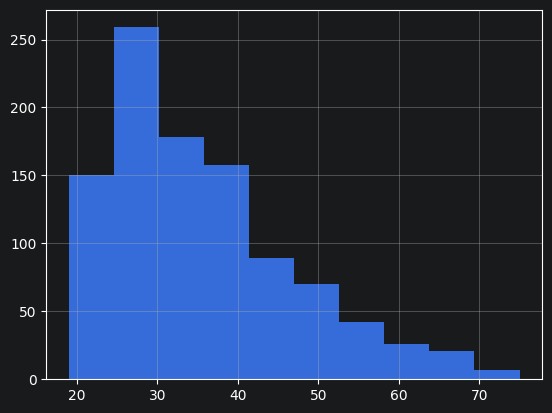

In [12]:
df["Age_years"].hist()

<Axes: >

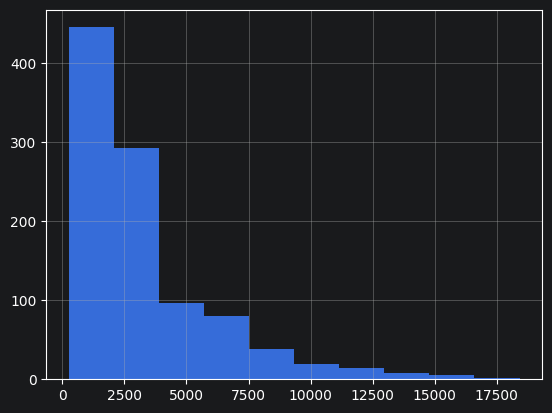

In [13]:
# print(df["Credit_Amount"])
df["Credit_Amount"].hist()

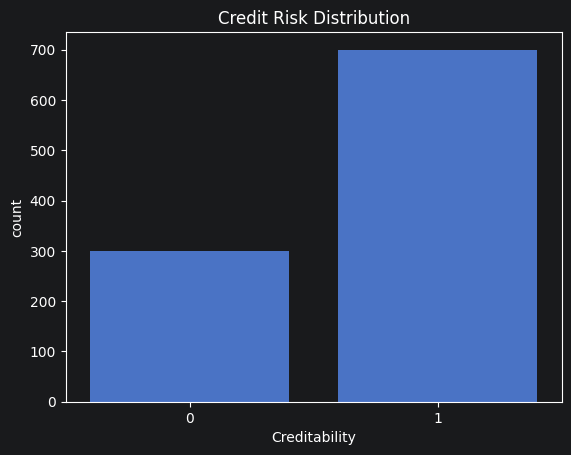

In [14]:
sns.countplot(x="Creditability", data=df)
plt.title("Credit Risk Distribution")
plt.show()

### Exploratory Data Analysis

In [15]:
df["Creditability"].value_counts()

Creditability
1    700
0    300
Name: count, dtype: int64

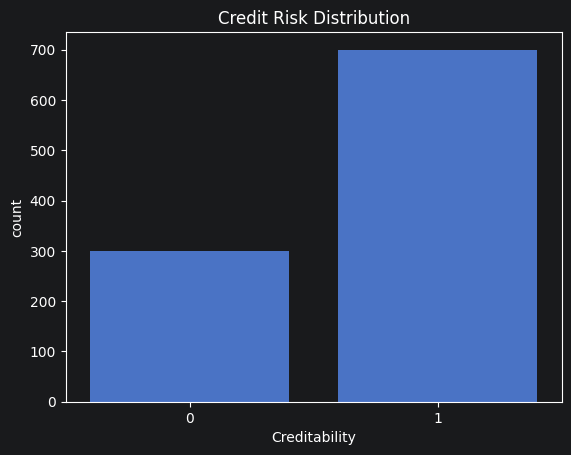

In [16]:
sns.countplot(x="Creditability", data=df)
plt.title("Credit Risk Distribution")
plt.show()

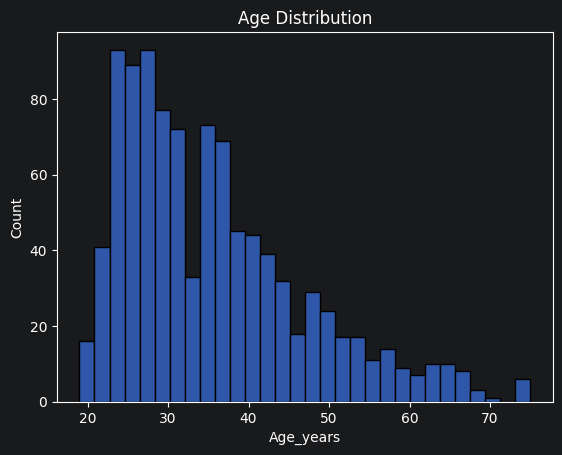

In [17]:
sns.histplot(df["Age_years"], bins=30)
plt.title("Age Distribution")
plt.show()

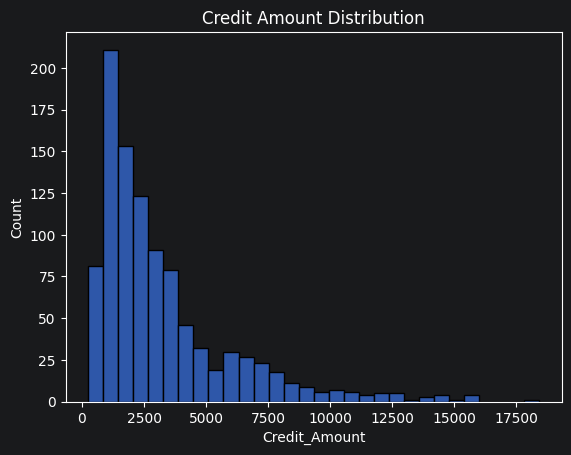

In [18]:
sns.histplot(df["Credit_Amount"], bins=30)
plt.title("Credit Amount Distribution")
plt.show()

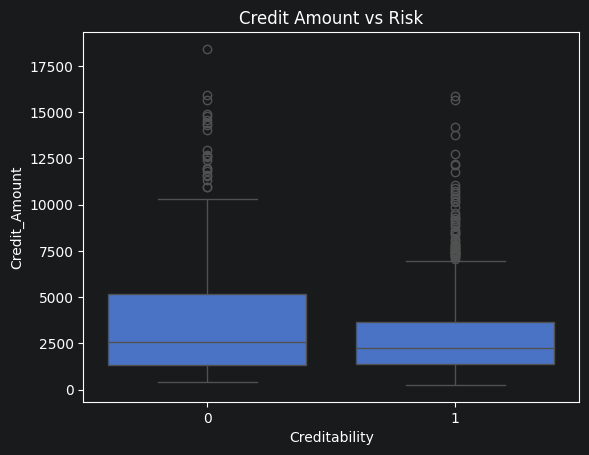

In [19]:
sns.boxplot(x="Creditability", y="Credit_Amount", data=df)
plt.title("Credit Amount vs Risk")
plt.show()

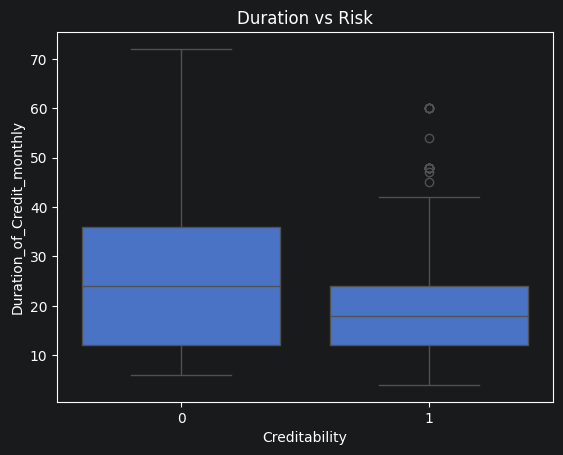

In [20]:
sns.boxplot(x="Creditability", y="Duration_of_Credit_monthly", data=df)
plt.title("Duration vs Risk")
plt.show()

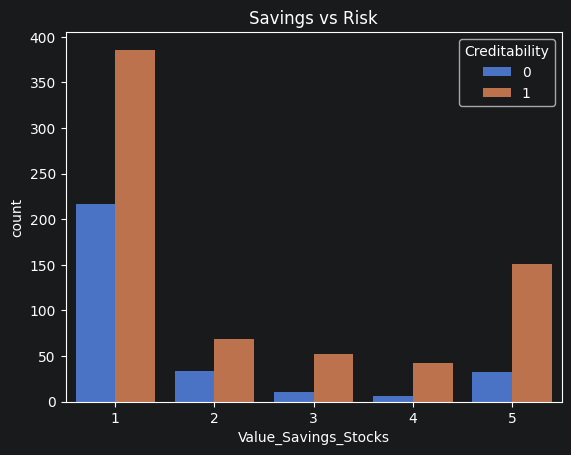

In [21]:
sns.countplot(x="Value_Savings_Stocks", hue="Creditability", data=df)
plt.title("Savings vs Risk")
plt.show()

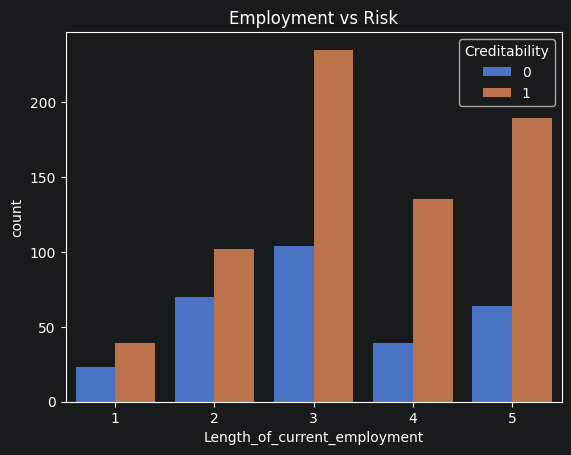

In [22]:
sns.countplot(x="Length_of_current_employment", hue="Creditability", data=df)
plt.title("Employment vs Risk")
plt.show()

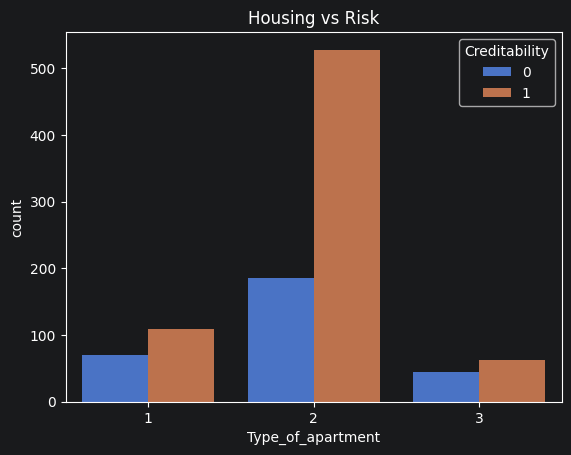

In [23]:
sns.countplot(x="Type_of_apartment", hue="Creditability", data=df)
plt.title("Housing vs Risk")
plt.show()

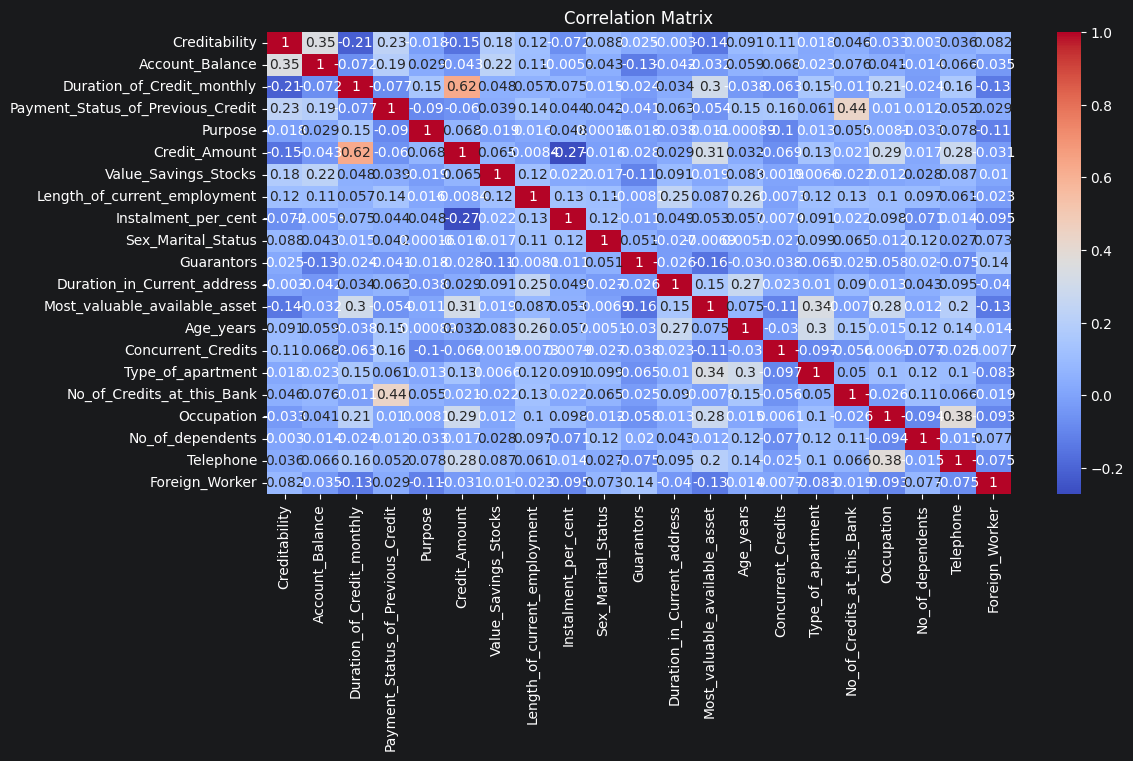

In [24]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

EDA Insights:

- Dataset has class imbalance
- Credit amount is higher for risky customers
- Longer duration increases risk
- Savings and employment strongly affect creditability
- Age has weak correlation

### Data Preprocessing

In [40]:
df.isnull().sum()

Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64

In [41]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include="object").columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [42]:
df[["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]] = df[["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]].astype(float)

In [43]:
X = df.drop("Creditability", axis=1)
y = df["Creditability"]

In [44]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 20)
(200, 20)


In [46]:
from sklearn.preprocessing import StandardScaler

#Scaling some values for Logistic Regression
scaler = StandardScaler()
X_train.loc[:, ["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]] = scaler.fit_transform( X_train[["Credit_Amount", "Age_years","Duration_of_Credit_monthly"]])
X_test.loc[:, ["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]] = scaler.transform( X_test[["Credit_Amount", "Age_years", "Duration_of_Credit_monthly"]] )

### Model Training

In [38]:
print(df["Purpose"])
# df.describe().loc["min"].sort_values(ascending=False)

0      2
1      0
2      9
3      0
4      0
      ..
995    3
996    0
997    0
998    3
999    2
Name: Purpose, Length: 1000, dtype: int64
